# Раздел 2. Практическая часть
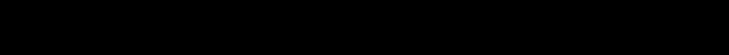
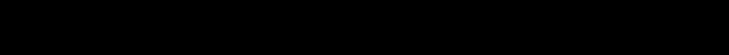

##  2.1 Предобработа данных

In [1]:
import pandas as pd
import numpy as np

In [2]:
df1 = pd.read_excel('X_bp.xlsx')
df1

,Unnamed: 0,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2"
0,0,1.857143,2030.000000,738.736842,30.000000,22.267857,100.000000,210.000000,70.000000,3000.000000,220.000000
1,1,1.857143,2030.000000,738.736842,50.000000,23.750000,284.615385,210.000000,70.000000,3000.000000,220.000000
2,2,1.857143,2030.000000,738.736842,49.900000,33.000000,284.615385,210.000000,70.000000,3000.000000,220.000000
3,3,1.857143,2030.000000,738.736842,129.000000,21.250000,300.000000,210.000000,70.000000,3000.000000,220.000000
4,4,2.771331,2030.000000,753.000000,111.860000,22.267857,284.615385,210.000000,70.000000,3000.000000,220.000000
...,...,...,...,...,...,...,...,...,...,...,...
1018,1018,2.271346,1952.087902,912.855545,86.992183,20.123249,324.774576,209.198700,73.090961,2387.292495,125.007669
1019,1019,3.444022,2050.089171,444.732634,145.981978,19.599769,254.215401,350.660830,72.920827,2360.392784,117.730099
1020,1020,3.280604,1972.372865,416.836524,110.533477,23.957502,248.423047,740.142791,74.734344,2662.906040,236.606764
1021,1021,3.705351,2066.799773,741.475517,141.397963,19.246945,275.779840,641.468152,74.042708,2071.715856,197.126067


In [3]:
df2 = pd.read_excel('X_nup.xlsx')
df2

,Unnamed: 0,"Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,0,0,4.000000,57.000000
1,1,0,4.000000,60.000000
2,2,0,4.000000,70.000000
3,3,0,5.000000,47.000000
4,4,0,5.000000,57.000000
...,...,...,...,...
1035,1035,90,8.088111,47.759177
1036,1036,90,7.619138,66.931932
1037,1037,90,9.800926,72.858286
1038,1038,90,10.079859,65.519479


In [4]:
df = df1.merge(df2, on='Unnamed: 0', how='inner')
df
df =  df.rename(columns={'Unnamed: 0': 'id'})
print(df.columns)
df.shape
df.set_index('id', inplace=True)
df.shape


Index(['id', 'Соотношение матрица-наполнитель', 'Плотность, кг/м3',
       'модуль упругости, ГПа', 'Количество отвердителя, м.%',
       'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2',
       'Поверхностная плотность, г/м2', 'Модуль упругости при растяжении, ГПа',
       'Прочность при растяжении, МПа', 'Потребление смолы, г/м2',
       'Угол нашивки, град', 'Шаг нашивки', 'Плотность нашивки'],
      dtype='str')


(1023, 13)

Фильтрация по предельно возможным значениям физических свойств

In [5]:
df1 = df[
    df['модуль упругости, ГПа'].between(40, 830) &
    df['Поверхностная плотность, г/м2'].between(20, 3000) &
    df['Шаг нашивки'].between(4, 10)
    ]
df1.shape

(469, 13)

Проверка на пропуски

In [6]:
df1.isna().sum()

Соотношение матрица-наполнитель         0
Плотность, кг/м3                        0
модуль упругости, ГПа                   0
Количество отвердителя, м.%             0
Содержание эпоксидных групп,%_2         0
Температура вспышки, С_2                0
Поверхностная плотность, г/м2           0
Модуль упругости при растяжении, ГПа    0
Прочность при растяжении, МПа           0
Потребление смолы, г/м2                 0
Угол нашивки, град                      0
Шаг нашивки                             0
Плотность нашивки                       0
dtype: int64

проверка на нулевые и отрицательные значения

In [ ]:
print(f"""Zero values in columns:\n{(df1 == 0).sum()},
\n
Negative values in columns:\n{(df1 < 0).sum()}""")


In [11]:
df=df1
df.shape

(469, 13)

In [12]:
df.to_excel('df469.xlsx', index=False)

In [ ]:
%store df

In [ ]:
df.dtypes
df.columns

In [ ]:
df.nunique()

**'Угол нашивки, град': пропорции и превращение в категорию**

In [ ]:
print(f'Единицы с углом нашивки 90 град: {len(df[df["Угол нашивки, град"]==90])}\nЕдиницы с углом нашивки 0 град: {len(df[df["Угол нашивки, град"]==0])}')

In [13]:
df=  df.assign(Тип_угла =df['Угол нашивки, град'].apply(lambda x: '0' if x == 0 else '90')
)

df.dtypes

Соотношение матрица-наполнитель         float64
Плотность, кг/м3                        float64
модуль упругости, ГПа                   float64
Количество отвердителя, м.%             float64
Содержание эпоксидных групп,%_2         float64
Температура вспышки, С_2                float64
Поверхностная плотность, г/м2           float64
Модуль упругости при растяжении, ГПа    float64
Прочность при растяжении, МПа           float64
Потребление смолы, г/м2                 float64
Угол нашивки, град                        int64
Шаг нашивки                             float64
Плотность нашивки                       float64
Тип_угла                                    str
dtype: object

In [14]:
df.drop('Угол нашивки, град', axis=1, inplace=True)


In [15]:
df.columns

Index(['Соотношение матрица-наполнитель', 'Плотность, кг/м3',
       'модуль упругости, ГПа', 'Количество отвердителя, м.%',
       'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2',
       'Поверхностная плотность, г/м2', 'Модуль упругости при растяжении, ГПа',
       'Прочность при растяжении, МПа', 'Потребление смолы, г/м2',
       'Шаг нашивки', 'Плотность нашивки', 'Тип_угла'],
      dtype='str')

Фильтрация данных по типу угла на две группы:

In [16]:
df_0 = df[df['Тип_угла']=='0']
df_0.drop('Тип_угла', axis=1, inplace=True)
df_90 = df[df['Тип_угла']=='90']
df_90.drop('Тип_угла', axis=1, inplace=True)
print(df_0.shape, df_90.shape)

(223, 12) (246, 12)


**Визуализация и решение проблемы зашумленности синтетическими данными**

Выявление дубликатов

In [ ]:
print(df.duplicated().sum())

**Визуализация распределения исходных данных**

1) Весь дата сет:

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='lightgreen')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [ ]:

fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightgreen', width=0.5)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Boxplot по переменным', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Тепловая карта корреляций
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляционная матрица')
plt.show()

# Парные графики
sns.pairplot(df[numeric_cols])
plt.show()

2) *Группа с типом угла 0:*

In [ ]:
numeric_cols_0 = df_0.columns.tolist()
numeric_cols_0

In [ ]:


fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.flat, numeric_cols_0):
    sns.histplot(df_0[col], kde=True, ax=ax)
    ax.set_title(col)
plt.suptitle('Гистограммы по переменным для угла 0', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for ax, col in zip(axes.flat, numeric_cols_0):
    sns.boxplot(y=df_0[col], ax=ax, color='lightblue', width=0.5)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Boxplot по переменным для угла 0', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Тепловая карта корреляций
plt.figure(figsize=(8,6))
sns.heatmap(df_0.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляционная матрица для угла 0')
plt.show()

# Парные графики
sns.pairplot(df_0)
plt.show()

3) *Группа с типом угла 90*

In [ ]:
numeric_cols_90 = df_90.columns.tolist()
numeric_cols_90

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.flat, numeric_cols_90):
    sns.histplot(df_90[col], kde=True, ax=ax, color='silver')
    ax.set_title(col)
plt.suptitle('Гистограммы по переменным для угла 90', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for ax, col in zip(axes.flat, numeric_cols_90):
    sns.boxplot(y=df_90[col], ax=ax, color='silver', width=0.5)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Boxplot по переменным для угла 90', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Тепловая карта корреляций
plt.figure(figsize=(8,6))
sns.heatmap(df_90.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляционная матрица для угла 90')
plt.show()

# Парные графики
sns.pairplot(df_90)
plt.show()

1) *По всем данным*

In [ ]:
outlier_results_df = []

for column in numeric_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    # Левый ус: максимум между расчетной границей и фактическим минимальным значением
    lower_bound = max(df[column].min(), Q1 - 1.5 * IQR)

    # Правый ус: мин между расчетной границей и фактическим максимальным значением
    upper_bound = min(df[column].max(), Q3 + 1.5 * IQR)

    df_no_outliers = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    outlier_ratio_df = round((((df.shape[0]) - len(df_no_outliers)) / len(df) * 100), 2)

    outlier_results_df.append({'Column': column, 'Outlier Ratio_All': outlier_ratio_df})

# Создание DataFrame с результатами по выбросам
outlier_results_df = pd.DataFrame(outlier_results_df)
outlier_results_df.loc[len(outlier_results_df)]=['В среднем', round(outlier_results_df['Outlier Ratio_All'].mean(), 2)]
outlier_results_df

2) *Для угла 0*

In [ ]:
outlier_results_df_0 = []

for column in numeric_cols:
    Q1 = df_0[column].quantile(0.25)
    Q3 = df_0[column].quantile(0.75)

    IQR = Q3 - Q1

    # Левый ус: максимум между расчетной границей и фактическим минимальным значением
    lower_bound = max(df_0[column].min(), Q1 - 1.5 * IQR)

    # Правый ус: мин между расчетной границей и фактическим максимальным значением
    upper_bound = min(df_0[column].max(), Q3 + 1.5 * IQR)

    df0_no_outliers = df_0[(df_0[column] >= lower_bound) & (df_0[column] <= upper_bound)]

    outlier_ratio_df_0 = round((((df_0.shape[0]) - len(df0_no_outliers)) / len(df_0) * 100), 2)

    outlier_results_df_0.append({'Column': column, 'Outlier Ratio_0': outlier_ratio_df_0})

# Создание DataFrame с результатами по выбросам
outlier_results_df_0 = pd.DataFrame(outlier_results_df_0)
outlier_results_df_0.loc[len(outlier_results_df_0)]=['В среднем', round(outlier_results_df_0['Outlier Ratio_0'].mean(), 2)]
outlier_results_df_0

3_*Для угла 90*

In [ ]:
outlier_results_df_90 = []

for column in numeric_cols:
    Q1 = df_90[column].quantile(0.25)
    Q3 = df_90[column].quantile(0.75)

    IQR = Q3 - Q1

    # Левый ус: максимум между расчетной границей и фактическим минимальным значением
    lower_bound = max(df_90[column].min(), Q1 - 1.5 * IQR)

    # Правый ус: мин между расчетной границей и фактическим максимальным значением
    upper_bound = min(df_90[column].max(), Q3 + 1.5 * IQR)

    df90_no_outliers = df_90[(df_90[column] >= lower_bound) & (df_90[column] <= upper_bound)]

    outlier_ratio_df_90 = round((((df_90.shape[0]) - len(df90_no_outliers)) / len(df_90) * 100), 2)

    outlier_results_df_90.append({'Column': column, 'Outlier Ratio_90': outlier_ratio_df_90})

# Создание DataFrame с результатами по выбросам
outlier_results_df_90 = pd.DataFrame(outlier_results_df_90)
outlier_results_df_90.loc[len(outlier_results_df_90)]=['В среднем', round(outlier_results_df_90['Outlier Ratio_90'].mean(), 2)]
outlier_results_df_90

*Сводная таблица сравнения процента выбросов*

In [ ]:
outlier_results = outlier_results_df_90.merge(outlier_results_df_0, on='Column', how='inner')
outlier_results = outlier_results.merge(outlier_results_df, on='Column', how='inner')
outlier_results

In [ ]:
numeric_cols

In [ ]:
df.describe().T
table = pd.DataFrame(df.describe().T)
table


## 2.2 ПОСТРОЕНИЕ МОДЕЛЕЙ

In [17]:
# Импорт библиотек
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [18]:
#   Разделение зависимых и независимых переменных:
X = df.drop(['Модуль упругости при растяжении, ГПа', 'Прочность при растяжении, МПа', 'Тип_угла'], axis=1)
X.shape


(469, 10)

In [19]:
Y_elast = df[['Модуль упругости при растяжении, ГПа']]
Y_strength = df['Прочность при растяжении, МПа']

In [20]:
# Разбиение на обучающую и тестовую выборки (60/40)
X_train, X_test, Y_elast_train, Y_elast_test, Y_strength_train, Y_strength_test  = train_test_split(X, Y_elast,Y_strength, test_size=0.4, random_state=42)


In [21]:
s = (X_train, X_test, Y_elast_train, Y_elast_test, Y_strength_train, Y_strength_test)
for i in s:
    print(len(i))


281
188
281
188
281
188


Модель Линейной регрессии

In [22]:
# Обучение для Y_elast

lr_elast = LinearRegression()
lr_elast.fit(X_train, Y_elast_train)
Y_elast_pred = lr_elast.predict(X_test)


In [23]:
# Обучение для Y_strength

lr_strength = LinearRegression()
lr_strength.fit(X_train, Y_strength_train)
Y_strength_pred = lr_strength.predict(X_test)
lr_strength.coef_

array([-5.30310447e+01, -6.77482166e-01,  2.75082078e-01, -1.83209328e-01,
        1.69239470e-01,  5.32548021e-01,  1.12342384e-02,  3.25065834e-01,
       -1.43682213e+01, -5.97727901e-01])

In [24]:
# Оценка для Y_elast
mae_elast = mean_absolute_error(Y_elast_test, Y_elast_pred)
rmse_elast = np.sqrt(mean_squared_error(Y_elast_test, Y_elast_pred))
r2_elast = r2_score(Y_elast_test, Y_elast_pred)

print(f'MAE: {mae_elast:.3f}')
print(f'RMSE: {rmse_elast:.3f}')
print(f'R²:  {r2_elast:.3f}')
coef_elast = pd.DataFrame(lr_elast.coef_, index=['Коэффициенты'], columns=X.columns).T
print(f'{coef_elast}\nПересечение:\n{lr_elast.intercept_}')


MAE: 2.347
RMSE: 3.000
R²:  -0.156
                                 Коэффициенты
Соотношение матрица-наполнитель     -0.181027
Плотность, кг/м3                    -0.003631
модуль упругости, ГПа                0.000229
Количество отвердителя, м.%         -0.022747
Содержание эпоксидных групп,%_2     -0.054914
Температура вспышки, С_2             0.010988
Поверхностная плотность, г/м2        0.000139
Потребление смолы, г/м2              0.000242
Шаг нашивки                          0.070776
Плотность нашивки                   -0.003319
Пересечение:
[80.69105936]


In [ ]:
# Оценка для Y_strength
mae_strength = mean_absolute_error(Y_strength_test, Y_strength_pred)
rmse_strengtht = np.sqrt(mean_squared_error(Y_strength_test, Y_strength_pred))
r2_strength = r2_score(Y_strength_test, Y_strength_pred)

print(f'MAE: {mae_strength:.3f}')
print(f'RMSE: {rmse_strengtht:.3f}')
print(f'R²:  {r2_strength:.3f}')
coef_strength = pd.DataFrame(lr_strength.coef_, index=['Коэффициенты'], columns=X.columns).T
print(f'{coef_strength}\nПересечение:\n{lr_strength.intercept_}')


Построение моделей на стандартизированных данных

In [26]:
Y_strength_train = pd.DataFrame(Y_strength_train)
Y_strength_test = pd.DataFrame(Y_strength_test)

In [27]:
# Стандартизация признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
Y_elast_train_scaled = scaler.fit_transform(Y_elast_train)
Y_elast_test_scaled = scaler.transform(Y_elast_test)
Y_strength_train_scaled = scaler.fit_transform(Y_strength_train)
Y_strength_test_scaled = scaler.transform(Y_strength_test)


In [28]:
Y_strength_train_scaled = scaler.fit_transform(Y_strength_train)
Y_strength_test_scaled = scaler.transform(Y_strength_test)

In [29]:
# Обучение и оценка модели линейной регрессии
lr_elast_scaled = LinearRegression()
lr_elast_scaled.fit(X_train_scaled, Y_elast_train_scaled)
Y_elast_pred_scaled = lr_elast_scaled.predict(X_test_scaled)

mae_elast_scaled = mean_absolute_error(Y_elast_test_scaled, Y_elast_pred_scaled)
rmse_elast_scaled = np.sqrt(mean_squared_error(Y_elast_test_scaled, Y_elast_pred_scaled))
r2_elast_scaled = r2_score(Y_elast_test_scaled, Y_elast_pred_scaled)

print(f'MAE: {mae_elast_scaled:.3f}')
print(f'RMSE: {rmse_elast_scaled:.3f}')
print(f'R²:  {r2_elast_scaled:.3f}')
coef_elast_scaled = pd.DataFrame(lr_elast_scaled.coef_, index=['Коэффициенты'], columns=X.columns).T
print(f'{coef_elast_scaled}\nПересечение:\n{lr_elast_scaled.intercept_}')

MAE: 0.721
RMSE: 0.922
R²:  -0.156
                                 Коэффициенты
Соотношение матрица-наполнитель     -0.048980
Плотность, кг/м3                    -0.080726
модуль упругости, ГПа                0.013917
Количество отвердителя, м.%         -0.210675
Содержание эпоксидных групп,%_2     -0.041070
Температура вспышки, С_2             0.137591
Поверхностная плотность, г/м2        0.012063
Потребление смолы, г/м2              0.004444
Шаг нашивки                          0.034230
Плотность нашивки                   -0.012520
Пересечение:
[1.98304568e-15]


**Регуляризация Ridge и Lasso с кросс-валидацией**


 Модель для прогнозирования параметра 'Модуль упругости при растяжении, ГПа'

In [30]:
# Ridge
ridge = Ridge()
param_grid = {'alpha': np.logspace(-3, 3, 20)}
ridge_cv = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, Y_elast_train)
ridge_best = ridge_cv.best_estimator_

# Lasso
lasso = Lasso(max_iter=10000)
lasso_cv = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_cv.fit(X_train_scaled, Y_elast_train)
lasso_best = lasso_cv.best_estimator_

# Прогнозы на тесте
y_pred_ridge = ridge_best.predict(X_test_scaled)
y_pred_lasso = lasso_best.predict(X_test_scaled)



2.3 Тестирование моделей

Метрики регуляризованных моделей:
         MAE   RMSE     R²
Ridge  2.260  2.903 -0.083
Lasso  2.254  2.896 -0.077

Коэффициенты Ridge: [-0.09607397 -0.13229867  0.02244819 -0.34884351 -0.07793734  0.22089823
  0.0149779   0.00541278  0.05252953 -0.03285862]
Коэффициенты Lasso: [-0.00649331 -0.09228936  0.         -0.48108208 -0.          0.27067991
  0.          0.          0.         -0.        ]
Лучший alpha для Ridge: 233.57214690901213
Лучший alpha для Lasso: 0.1623776739188721


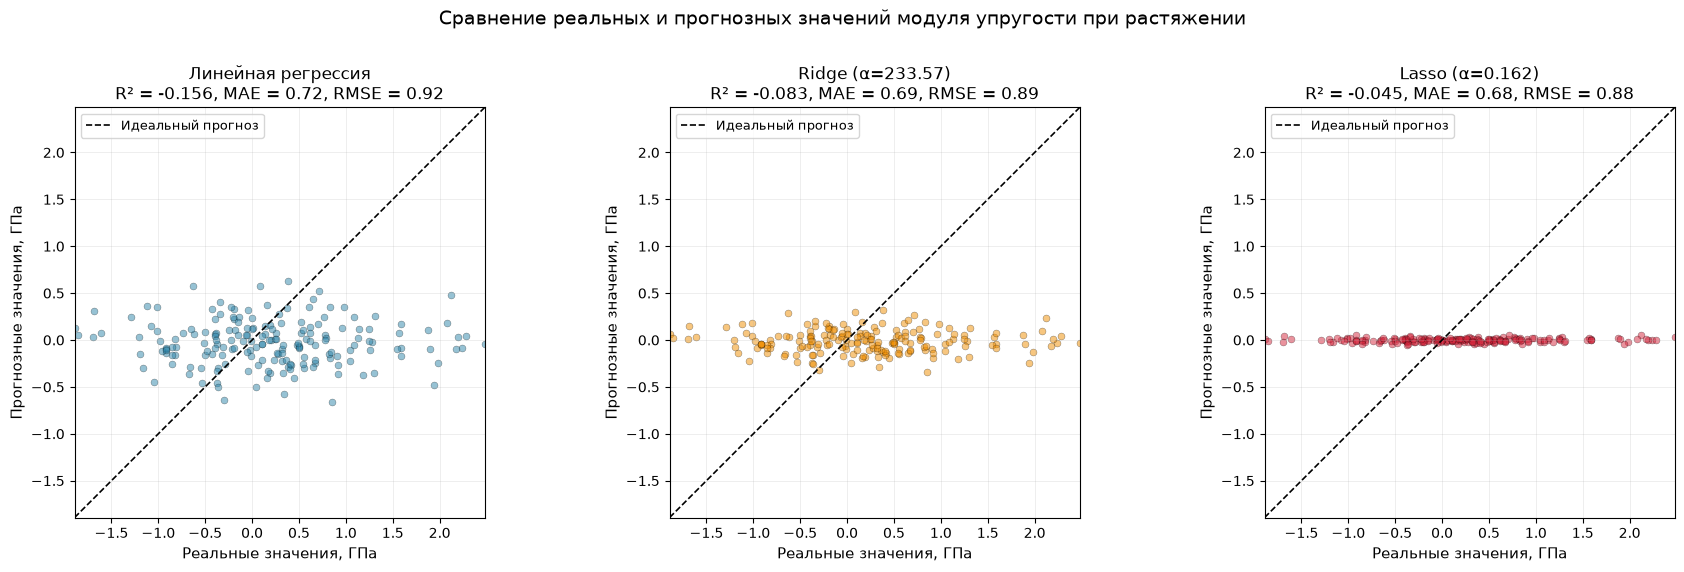

In [31]:
# Таблица метрик
metrics = pd.DataFrame({
    'MAE': [mean_absolute_error(Y_elast_test, y_pred_ridge), mean_absolute_error(Y_elast_test, y_pred_lasso)],
    'RMSE': [np.sqrt(mean_squared_error(Y_elast_test, y_pred_ridge)), np.sqrt(mean_squared_error(Y_elast_test, y_pred_lasso))],
    'R²': [r2_score(Y_elast_test, y_pred_ridge), r2_score(Y_elast_test, y_pred_lasso)]
}, index=['Ridge', 'Lasso'])
print('Метрики регуляризованных моделей:')
print(metrics.round(3))

print('\nКоэффициенты Ridge:', ridge_best.coef_)
print('Коэффициенты Lasso:', lasso_best.coef_)
print('Лучший alpha для Ridge:', ridge_cv.best_params_['alpha'])
print('Лучший alpha для Lasso:', lasso_cv.best_params_['alpha'])


# Построение совместного графика соотношения тестовых и прогнозных значений
lr = LinearRegression()
lr.fit(X_train_scaled, Y_elast_train_scaled)
y_pred_lr = lr.predict(X_test_scaled)

ridge = Ridge(alpha=233.57)   # лучшее α из GridSearchCV
ridge.fit(X_train_scaled, Y_elast_train_scaled)
y_pred_ridge = ridge.predict(X_test_scaled)

lasso = Lasso(alpha=0.162, max_iter=10000)
lasso.fit(X_train_scaled, Y_elast_train_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)

#  1 строка, 3 колонки:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

models = [
    ('Линейная регрессия', y_pred_lr, '#2E86AB'),
    ('Ridge (α=233.57)',   y_pred_ridge, '#F18F01'),
    ('Lasso (α=0.162)',    y_pred_lasso, '#D7263D'),
]

for ax, (name, y_pred, color) in zip(axes, models):
    # Точки: реальные vs прогнозные
    ax.scatter(Y_elast_test_scaled, y_pred, alpha=0.5, s=25, color=color,
               edgecolor='black', linewidth=0.3)

    # Линия идеального прогноза y = x
    lims = [min(Y_elast_test_scaled.min(), y_pred.min()),
            max(Y_elast_test_scaled.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Идеальный прогноз')

    # Метрики
    r2 = r2_score(Y_elast_test_scaled, y_pred)
    mae = mean_absolute_error(Y_elast_test_scaled, y_pred)
    rmse = np.sqrt(mean_squared_error(Y_elast_test_scaled, y_pred))

    ax.set_xlabel('Реальные значения, ГПа', fontsize=11)
    ax.set_ylabel('Прогнозные значения, ГПа', fontsize=11)
    ax.set_title(f'{name}\nR² = {r2:.3f}, MAE = {mae:.2f}, RMSE = {rmse:.2f}',
                 fontsize=12)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Сравнение реальных и прогнозных значений модуля упругости при растяжении',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('output/scatter_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

2.4 Нейронная сеть для рекомендации соотношения матрица-наполнитель

Модели MLP и CatBoost

In [ ]:
# pip install catboost

In [36]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import pickle
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

df = pd.read_excel('df469.xlsx')
df.rename(columns={'модуль упругости, ГПа': 'Mодуль упругости, ГПа'}, inplace=True)
# Фиксация сидов для строгого сравнения на одинаковых условиях
torch.manual_seed(42)
np.random.seed(42)
# 1. ПОДГОТОВКА ДАННЫХ И ИСПРАВЛЕНИЕ ИМЕН КОЛОНОК

feature_cols = [
    'Плотность, кг/м3', 'Mодуль упругости, ГПа', 'Количество отвердителя, м.%',
    'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2', 'Поверхностная плотность, г/м2',
    'Модуль упругости при растяжении, ГПа', 'Прочность при растяжении, МПа',
    'Потребление смолы, г/м2', 'Шаг нашивки', 'Плотность нашивки'
]
target_col = 'Соотношение матрица-наполнитель'

X = df[feature_cols].values
y = df[target_col].values.reshape(-1, 1)


# 2. АРХИТЕКТУРА НЕЙРОННОЙ СЕТИ

class CompositeMLP(nn.Module):
    def __init__(self, input_dim):
        super(CompositeMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.35),  # Защита от переобучения

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)


# 3. КРОСС-ВАЛИДАЦИЯ И СРАВНЕНИЕ МОДЕЛЕЙ

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Списки для хранения метрик по каждому фолду
nn_metrics = {'r2': [], 'mae': [], 'rmse': []}
cb_metrics = {'r2': [], 'mae': [], 'rmse': []}

print(f"Запуск кросс-валидации на {len(df)} строках...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    # Разделение данных
    X_train_f, X_val_f = X[train_idx], X[val_idx]
    y_train_f, y_val_f = y[train_idx], y[val_idx]

    # Масштабирование
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train_f)
    X_val_scaled = scaler_X.transform(X_val_f)

    y_train_scaled = scaler_y.fit_transform(y_train_f)
    y_val_scaled = scaler_y.transform(y_val_f)

    # ----------- ЧАСТЬ 1: ОБУЧЕНИЕ НЕЙРОСЕТИ (PyTorch) -----------
    X_train_t = torch.FloatTensor(X_train_scaled)
    y_train_t = torch.FloatTensor(y_train_scaled)
    X_val_t = torch.FloatTensor(X_val_scaled)
    y_val_t = torch.FloatTensor(y_val_scaled)

    nn_model = CompositeMLP(input_dim=len(feature_cols))
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(nn_model.parameters(), lr=0.01, weight_decay=1e-3)  # L2 регуляризация

    best_val_loss = float('inf')
    patience, patience_counter = 15, 0
    best_model_state = None

    for epoch in range(200):
        nn_model.train()
        optimizer.zero_grad()
        loss = criterion(nn_model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()

        nn_model.eval()
        with torch.no_grad():
            val_loss = criterion(nn_model(X_val_t), y_val_t).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = nn_model.state_dict().copy()
        else:
            patience_counter += 1
        if patience_counter >= patience:
            break

    nn_model.load_state_dict(best_model_state)
    nn_model.eval()
    with torch.no_grad():
        nn_preds_scaled = nn_model(X_val_t).numpy()
        nn_preds = scaler_y.inverse_transform(nn_preds_scaled)
    # ----------- ЧАСТЬ 2: ОБУЧЕНИЕ CATBOOST -----------
    # Настраиваем параметры под малую выборку
    cb_model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.03,
        depth=4,  # Неглубокие деревья, чтобы не переобучаться
        l2_leaf_reg=5,  # Регуляризация листьев
        random_seed=42,
        verbose=False  # Отключаем вывод логов обучения
    )

    # Обучаем CatBoost на немасштабированном Y
    cb_model.fit(X_train_scaled, y_train_f.ravel(), eval_set=(X_val_scaled, y_val_f.ravel()), early_stopping_rounds=30)
    cb_preds = cb_model.predict(X_val_scaled)
    # ----------- СБОР МЕТРИК -----------
    # Нейросеть
    nn_metrics['r2'].append(r2_score(y_val_f, nn_preds))
    nn_metrics['mae'].append(mean_absolute_error(y_val_f, nn_preds))
    nn_metrics['rmse'].append(np.sqrt(mean_squared_error(y_val_f, nn_preds)))

    # Бустинг
    cb_metrics['r2'].append(r2_score(y_val_f, cb_preds))
    cb_metrics['mae'].append(mean_absolute_error(y_val_f, cb_preds))
    cb_metrics['rmse'].append(np.sqrt(mean_squared_error(y_val_f, cb_preds)))

    print(f"Фолд {fold + 1} | ИНС R²: {nn_metrics['r2'][-1]:.3f} vs CatBoost R²: {cb_metrics['r2'][-1]:.3f}")

# 4. СРАВНЕНИЕ МЕТРИК

results_df = pd.DataFrame({
    'Метрика': ['MAE', 'RMSE', 'R²'],
    'Нейросеть (PyTorch)': [np.mean(nn_metrics['mae']), np.mean(nn_metrics['rmse']), np.mean(nn_metrics['r2'])],
    'CatBoost': [np.mean(cb_metrics['mae']), np.mean(cb_metrics['rmse']), np.mean(cb_metrics['r2'])]
}).set_index('Метрика')

print("_" * 55)
print("СРАВНЕНИЕ МЕТРИК:СРЕДНИЕ ЗНАЧЕНИЯ ПО КРОСС-ВАЛИДАЦИИ")
print("_" * 55)
print(results_df.round(4))

# 5. Сохранение файлов для GUI-приложения
MODEL_FILE = 'base_catboost_model.cbm'
cb_model.save_model(MODEL_FILE)
print(f"\nБазовая модель CatBoost успешно сохранена в файл '{MODEL_FILE}'")

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)



Запуск кросс-валидации на 469 строках...

Фолд 1 | ИНС R²: -0.041 vs CatBoost R²: 0.002
Фолд 2 | ИНС R²: -0.035 vs CatBoost R²: -0.003
Фолд 3 | ИНС R²: -0.128 vs CatBoost R²: -0.022
Фолд 4 | ИНС R²: -0.075 vs CatBoost R²: -0.014
Фолд 5 | ИНС R²: -0.087 vs CatBoost R²: 0.007
_______________________________________________________
СРАВНЕНИЕ МЕТРИК:СРЕДНИЕ ЗНАЧЕНИЯ ПО КРОСС-ВАЛИДАЦИИ
_______________________________________________________
         Нейросеть (PyTorch)  CatBoost
Метрика                               
MAE                   0.7399    0.7230
RMSE                  0.9185    0.8898
R²                   -0.0734   -0.0059

Базовая модель CatBoost успешно сохранена в файл 'base_catboost_model.cbm'


## **2.5 Разработка приложения**
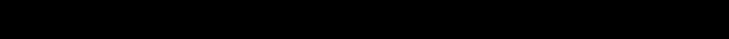

In [37]:
import os
import pickle
import tkinter as tk
from tkinter import ttk, messagebox
import numpy as np
from catboost import CatBoostRegressor

# Константы путей к сохраненным файлам
MODEL_FILE = 'base_catboost_model.cbm'
SCALER_FILE = 'scaler.pkl'

# Список признаков  ( как в модели)
feature_cols = [
    'Плотность, кг/м3', 'Mодуль упругости, ГПа', 'Количество отвердителя, м.%',
    'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2', 'Поверхностная плотность, г/м2',
    'Модуль упругости при растяжении, ГПа', 'Прочность при растяжении, МПа',
    'Потребление смолы, г/м2', 'Шаг нашивки', 'Плотность нашивки'
]


# 1. ПРОВЕРКА НАЛИЧИЯ И ЗАГРУЗКА ФАЙЛОВ МОДЕЛИ

if not os.path.exists(MODEL_FILE) or not os.path.exists(SCALER_FILE):
    # Если файлов нет, приложение предупредит и закроется
    root_error = tk.Tk()
    root_error.withdraw()
    messagebox.showerror(
        "Ошибка запуска",
        f"Не найдены обязательные файлы модели или скейлера!\n\n"
        f"Убедитесь, что файлы '{MODEL_FILE}' и '{SCALER_FILE}' "
        f"находятся в одной папке со скриптом приложения."
    )
    exit()

# Загружаем скейлер
with open(SCALER_FILE, 'rb') as f:
    scaler = pickle.load(f)

# Загружаем базовую модель CatBoost
model = CatBoostRegressor()
model.load_model(MODEL_FILE)


# 2. ИНТЕРФЕЙС ПРИЛОЖЕНИЯ (GUI)

class BaseCompositeApp(tk.Tk):
    def __init__(self):
        super().__init__()

        self.title("Базовая модель расчета параметров ПКМ")
        self.geometry("760x560")
        self.resizable(False, False)

        # Словарь текстовых переменных полей ввода
        self.inputs = {}
        self.create_widgets()

    def create_widgets(self):
        # Главная рамка
        main_frame = ttk.Frame(self, padding="20")
        main_frame.pack(fill=tk.BOTH, expand=True)

        # Верхний информационный блок
        title_label = ttk.Label(
            main_frame,
            text="Определение соотношения матрица-наполнитель (Базовая модель)",
            font=("Helvetica", 12, "bold")
        )
        title_label.grid(row=0, column=0, columnspan=2, pady=(0, 15), sticky="w")

        # ЛЕВАЯ СТОРОНА: Поля для 11 признаков
        input_frame = ttk.LabelFrame(main_frame, text=" Входные характеристики композита ", padding="10")
        input_frame.grid(row=1, column=0, sticky="nsew", padx=(0, 15))

        for idx, col_name in enumerate(feature_cols):
            label = ttk.Label(input_frame, text=f"{col_name}:", font=("Helvetica", 9))
            label.grid(row=idx, column=0, sticky="w", pady=4, padx=5)

            var = tk.StringVar()
            var.set("0.0") # Значение по умолчанию для полей ввода

            entry = ttk.Entry(input_frame, textvariable=var, width=15, justify="right")
            entry.grid(row=idx, column=1, sticky="e", pady=4, padx=5)

            self.inputs[col_name] = var

        # ПРАВАЯ СТОРОНА: Управление и вывод
        right_frame = ttk.Frame(main_frame)
        right_frame.grid(row=1, column=1, sticky="nsew")

        desc_text = (
            "Данная версия приложения использует модель CatBoost "
            "(без автоматического поиска гиперпараметров).\n\n"
            "Заполните числовые показатели слева и нажмите кнопку ниже."
        )
        desc_label = ttk.Label(right_frame, text=desc_text, wraplength=280, justify="left", font=("Helvetica", 10))
        desc_label.pack(anchor="w", pady=(10, 25))

        # Кнопка выполнения расчета
        self.calc_btn = ttk.Button(right_frame, text="Выполнить расчет", command=self.calculate)
        self.calc_btn.pack(fill=tk.X, ipady=12, pady=(0, 40))

        # Рамка вывода ответа
        result_frame = ttk.LabelFrame(right_frame, text=" Рекомендуемое значение ", padding="15")
        result_frame.pack(fill=tk.X)

        self.result_value = ttk.Label(
            result_frame,
            text="---",
            font=("Helvetica", 22, "bold"),
            foreground="#2e7d32" # Зеленый цвет для индикации успешного расчета базовой модели
        )
        self.result_value.pack(pady=5)

        target_label = ttk.Label(result_frame, text="Соотношение матрица-наполнитель", font=("Helvetica", 9, "italic"))
        target_label.pack()

    def calculate(self):
        """Обработка нажатия кнопки расчета."""
        raw_values = []

        # 1. Извлечение и валидация
        for col_name in feature_cols:
            val_str = self.inputs[col_name].get().replace(',', '.')
            try:
                val_float = float(val_str)
                raw_values.append(val_float)
            except ValueError:
                messagebox.showerror(
                    "Ошибка данных",
                    f"В поле '{col_name}' обнаружено некорректное значение. Допускаются только числа."
                )
                return

        # 2. Масштабирование через загруженный StandardScaler
        input_array = np.array(raw_values).reshape(1, -1)
        input_scaled = scaler.transform(input_array)

        # 3. Предсказание базовой моделью CatBoost
        try:
            prediction = model.predict(input_scaled)[0]

            # Физический сдерживатель (пропорция не может быть ниже нуля)
            if prediction < 0:
                prediction = 0.0

            # Отображаем результат
            self.result_value.config(text=f"{prediction:.4f}")

        except Exception as e:
            messagebox.showerror("Критическая ошибка", f"Модель не смогла рассчитать параметр:\n{str(e)}")


# 3. ТОЧКА ВХОДА В GUI

if __name__ == "__main__":
    app = BaseCompositeApp()
    app.mainloop()


KeyboardInterrupt: 